**Import the useful packages** 

In [1]:
import numpy as np
import xarray as xr
import glob
import matplotlib.pyplot as plt
import os,sys
import pandas as pd

# To avoid problems with tensorflow, add the following lines before importing it
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow import keras

# To avoid problems with nn_functions, add the following lines before importing it 
import sys
sys.path.insert(1, '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt')

#from nn_functions.constants import *
#import nn_functions.diagnostic_functions as diag
#import nn_functions.data_formatting as dfmt
import nn_functions.postprocessing_functions as pp
#from nn_functions.constants import *

import define_params 

# For plotting things on the polar stereographic grid with lat and lon coordinates 
import cartopy.crs as ccrs
proj=ccrs.SouthPolarStereo(central_longitude=0.0)
trans=ccrs.PlateCarree()

**Set the filepaths to the input and output data** 

In [2]:
path_model = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/NN_models/'
path_norm_metrics = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/'

models = glob.glob(path_model + '*.keras')
histories = glob.glob(path_model + 'history*.csv')

#fp_all_data = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/whole_dataset_not_yet_normalised.csv'


In [3]:
#mod_size = 'small'
#TS_opt = 'extrap'
#norm_method = 'std'
#exp_name = 'slope_front'
#annual_f = ''
#seed_nb = 1
#this_collection = 'no_middle_5'
#np.random.seed(seed_nb)
#tf.random.set_seed(seed_nb)

### **Look at the characteristics of a datasett**

Use functions to:
- Load in the test data

In [4]:
# Load in all the data
def load_test_data_whole_sim(this_collection, verbose = 0, keep_pandas = False):
    fp_apply = path_norm_metrics + this_collection + '_not_yet_normalised.csv'
    df_sel = pd.read_csv(fp_apply)
    print('\033[1m' + 'You have loaded data to apply the nn to:' + '\033[0m')
    print(fp_apply)
    print('You have kept the whole dataset')
    # Convert imported data to xarray
    if keep_pandas == False:
        clean_df = df_sel.to_xarray()
        return clean_df
    else:
        return df_sel

In [5]:
# Set the model filepath and load the normalisation metrics 
def load_model_nn(exp_name, this_collection, seed_nb, mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0, 
                 annual_f = ''):
    fp_model = path_model + 'model_nn_'+ mod_size + '_' +exp_name + '_' + this_collection + '_' + annual_f + \
                                    str(seed_nb).zfill(2) + '_' + TS_opt + '_' + norm_method + '.keras'
    model = keras.models.load_model(fp_model)
    if verbose == 1:
        print('\033[1m' + 'You have loaded a trained neural network:' + '\033[0m')
        print(fp_model)
    return model
    
def load_normalisation_metrics(this_collection, norm_method = 'std', verbose = 0):
    fp_norm_metrics = path_norm_metrics + this_collection + '_metrics_norm.nc'
    norm_metrics_file = xr.open_dataset(fp_norm_metrics)
    if verbose > 0:
        print('\033[1m' + 'You have loaded normalisation metrics:' + '\033[0m')
        print(fp_norm_metrics)
    norm_metrics = norm_metrics_file.sel(norm_method=norm_method).drop('norm_method').to_dataframe()
    return norm_metrics

In [6]:
this_collection_NN = 'OPM026_whole_dataset'
this_collection_apply = 'OPM031_whole_dataset'
exp_name = 'slope_front'

In [7]:
OPM026 = load_test_data_whole_sim(this_collection_NN, keep_pandas = True)
OPM031 = load_test_data_whole_sim(this_collection_apply, keep_pandas = True)

You have loaded data to apply the nn to:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM026_whole_dataset_not_yet_normalised.csv
You have kept the whole dataset
You have loaded data to apply the nn to:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM031_whole_dataset_not_yet_normalised.csv
You have kept the whole dataset


In [8]:
OPM0263 = load_test_data_whole_sim('OPM0263_whole_dataset', keep_pandas = True)

You have loaded data to apply the nn to:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM0263_whole_dataset_not_yet_normalised.csv
You have kept the whole dataset


In [12]:
#OPM031_ymb = OPM031.groupby(['year', 'month', 'basins_NEMO'], as_index = False).mean()

In [13]:
salinity_weights = [
    OPM026.salinity_prop,
    OPM0263.salinity_prop,
    OPM031.salinity_prop,
]

temperature_weights = [
    OPM026.temperature_prop,
    OPM0263.temperature_prop,
    OPM031.temperature_prop,
]

distance_weights = [
    OPM026.distances_OC.values,
    OPM0263.distances_OC.values,
    OPM031.distances_OC.values,
]

slope_weights = [
     OPM026.slope_is_towards_front.values,
    OPM0263.slope_is_towards_front.values,
    OPM031.slope_is_towards_front.values,
]

slope_weights2 = [
     OPM026.slope_is_across_front.values,
    OPM0263.slope_is_across_front.values,
    OPM031.slope_is_across_front.values,
]


labels = ['Training simulation\nPresent day conditions', 'Test simulation\nPresent day conditions', 'Test simulation\nFuture conditions']
colors = ['peachpuff', 'orange', 'tomato']


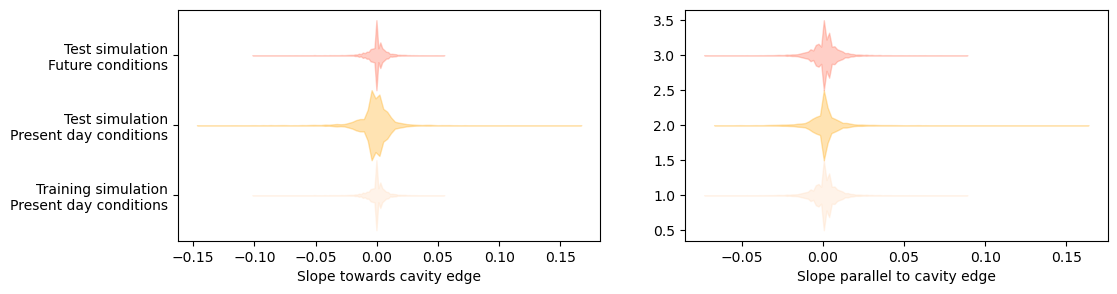

In [14]:
fig, ax = plt.subplots(1,2, figsize = (12,3))
ax[0].set_xlabel('Slope towards cavity edge')
ax[1].set_xlabel('Slope parallel to cavity edge')

bplot = ax[0].violinplot(slope_weights, vert = False, widths = 1, showmedians=False, showextrema=False)  # will be used to label x-ticks
for pc, color in zip(bplot['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_edgecolor(color)

bplot = ax[1].violinplot(slope_weights2, vert = False, widths = 1, showmedians=False, showextrema=False)  # will be used to label x-ticks
for pc, color in zip(bplot['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_edgecolor(color)

#bplot['cmedians'].set_colors(colors)
#bplot['cbars'].set_colors(colors)
#bplot['cmins'].set_colors(colors)
#bplot['cmaxes'].set_colors(colors)

ax[0].set_yticks([1, 2, 3], labels=labels)

#fig.savefig('FIGURES/Poten.png', dpi = 200, bbox_inches = 'tight')

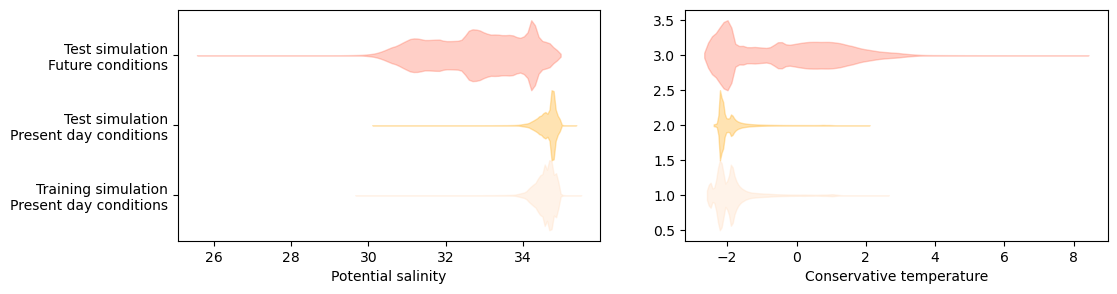

In [15]:
fig, ax = plt.subplots(1,2, figsize = (12,3))
ax[0].set_xlabel('Potential salinity')
ax[1].set_xlabel('Conservative temperature')

bplot = ax[0].violinplot(salinity_weights, vert = False, widths = 1, showmedians=False, showextrema=False)  # will be used to label x-ticks
for pc, color in zip(bplot['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_edgecolor(color)

bplot = ax[1].violinplot(temperature_weights, vert = False, widths = 1, showmedians=False, showextrema=False)  # will be used to label x-ticks
for pc, color in zip(bplot['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_edgecolor(color)

#bplot['cmedians'].set_colors(colors)
#bplot['cbars'].set_colors(colors)
#bplot['cmins'].set_colors(colors)
#bplot['cmaxes'].set_colors(colors)

ax[0].set_yticks([1, 2, 3], labels=labels)

#fig.savefig('FIGURES/Poten.png', dpi = 200, bbox_inches = 'tight')

In [16]:
# Look at the possible distributions of mixing simulation data 

In [20]:
OPM026[OPM026.year < 2059]

,lat,lon,distances_GL,distances_OO,distances_OC,temperature_prop,salinity_prop,melt_m_ice_per_y,corrected_isdraft,bathymetry,...,slope_is_towards_front,slope_ba_across_front,slope_ba_towards_front,mean_T,mean_S,std_T,std_S,year,month,basins_NEMO
0,-85.396736,-152.77846,3809.706697,744266.590479,155031.795156,-2.169899,34.856243,-0.000030,988.770020,1037.908569,...,0.004954,-0.013651,-0.011785,-2.166945,34.855318,0.020488,0.012357,1979,1,59.0
1,-85.368385,-154.12903,3824.406974,737830.168777,143376.499204,-2.169899,34.856243,-0.000021,901.829529,943.754639,...,-0.000000,-0.023461,-0.020255,-2.166945,34.855318,0.020488,0.012357,1979,1,59.0
2,-85.365005,-153.69621,4287.263604,738553.726966,146370.510902,-2.169899,34.856243,-0.000086,1012.748047,1064.429688,...,0.005162,-0.000000,-0.000000,-2.166945,34.855318,0.020488,0.012357,1979,1,59.0
3,-85.361430,-153.26420,4284.087686,739302.729521,149404.836207,-2.169899,34.856243,-0.000093,1012.748047,1092.512817,...,0.005165,-0.000000,-0.000000,-2.166945,34.855318,0.020488,0.012357,1979,1,59.0
4,-85.357635,-152.83304,5732.861259,740075.392643,152476.030358,-2.169899,34.856243,-0.000061,965.817993,1092.512817,...,0.000006,-0.006639,-0.005731,-2.166945,34.855318,0.020488,0.012357,1979,1,59.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881595,-65.078710,97.00000,48982.662530,11997.152819,11997.152819,-1.688876,34.498745,-0.000009,75.150322,382.510223,...,0.000424,-0.001911,-0.000233,-1.875661,34.531327,0.030013,0.035702,2058,12,26.0
10881596,-65.078710,-60.75000,16993.429796,11957.454165,11957.454165,-1.812179,34.705578,-0.000020,127.891647,254.796600,...,-0.004361,-0.009517,-0.007234,-1.443037,34.669696,0.317585,0.026433,2058,12,113.0
10881597,-65.078710,-60.50000,26878.520294,11957.454165,11957.454165,-1.588502,34.677715,-0.000024,94.217178,239.446716,...,-0.000705,0.001439,0.001094,-1.443037,34.669696,0.317585,0.026433,2058,12,113.0
10881598,-64.973160,-60.75000,12049.551972,12060.645320,12060.645320,-0.947401,34.632263,-0.000105,66.691956,153.289978,...,-0.004361,-0.009517,-0.007234,-1.443037,34.669696,0.317585,0.026433,2058,12,113.0


In [42]:
#OPM_mix = pd.concat([OPM031[OPM031.year > 2088], OPM026[OPM026.year < 2059]], ignore_index=True)
OPM_mix = pd.concat([OPM031[OPM031.year > 2088], OPM026[OPM026.year < 2019]], ignore_index=True)
OPM031_beginning = OPM031[OPM031.year < 2079]

In [43]:
salinity_weights = [
    OPM_mix.salinity_prop,
    OPM031_beginning.salinity_prop,
]

temperature_weights = [
    OPM_mix.temperature_prop,
    OPM031_beginning.temperature_prop,
]

labels = ['Training simulation\nPresent day conditions + last 10 yrs future', 'Test simulation\nFuture conditions (First 80 yrs)']
colors = ['peachpuff', 'tomato']

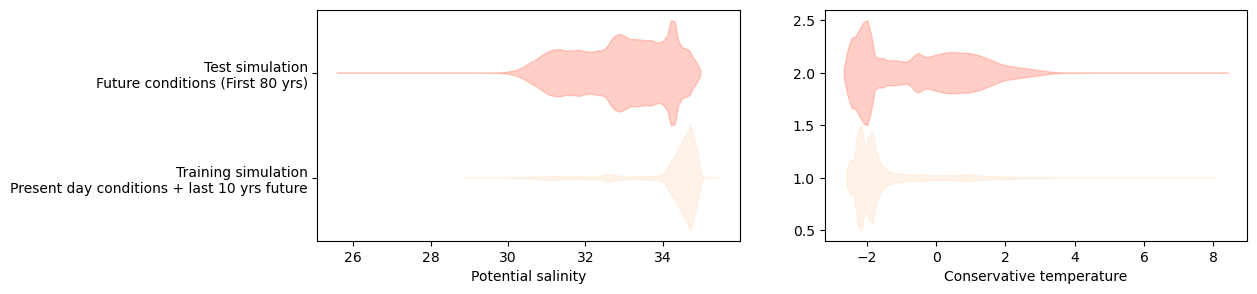

In [44]:
fig, ax = plt.subplots(1,2, figsize = (12,3))
ax[0].set_xlabel('Potential salinity')
ax[1].set_xlabel('Conservative temperature')

bplot = ax[0].violinplot(salinity_weights, vert = False, widths = 1, showmedians=False, showextrema=False)  # will be used to label x-ticks
for pc, color in zip(bplot['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_edgecolor(color)

bplot = ax[1].violinplot(temperature_weights, vert = False, widths = 1, showmedians=False, showextrema=False)  # will be used to label x-ticks
for pc, color in zip(bplot['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_edgecolor(color)

ax[0].set_yticks([1, 2], labels=labels)

#fig.savefig('FIGURES/Poten.png', dpi = 200, bbox_inches = 'tight')